# Non Stationary Trasnformer Playground

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import specialized Prophet functions
from src.models.ns_transformer.train import (
    load_processed_data, 
    train_models, 
    predict_models, 
    evaluate_models,
    save_artifacts
)
from src.tools import plot_cluster_portfolio, analyze_time_periods, plot_mape_vs_volume
from src.config import TEST_CUTOFF_DT

## 1. Global Data Loading

We load the global processed dataset once. It contains all features, including the raw consumption and weather signals that will be scaled differently depending on the forecast mode.

In [2]:
data_path = os.path.join(PROJECT_ROOT, 'data', 'processed_retail_data.parquet')
df_long = load_processed_data(data_path)
df_long.head()

Loading processed data...


,StockCode,Week,Quantity,Revenue,week_of_year,month,quarter,year,sin_woy,cos_woy,...,volume_tier,semantic_cluster_name,ADI,CV2,demand_class,share_zero_weeks,price_median,mean_basket_size,n_unique_customers,country_uk_share
0,10080,2009-11-30,4,3.4,49,11,4,2009,-3.546049e-01,0.935016,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
1,10080,2009-12-07,0,0.0,50,12,4,2009,-2.393157e-01,0.970942,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
2,10080,2009-12-14,0,0.0,51,12,4,2009,-1.205367e-01,0.992709,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
3,10080,2009-12-21,0,0.0,52,12,4,2009,6.432491e-16,1.000000,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0
4,10080,2009-12-28,0,0.0,53,12,4,2009,1.205367e-01,0.992709,...,Low,WRAP + BLUE + COVER,8.363636,1.309806,lumpy,0.880435,0.39,10.533333,12.0,1.0


## 2. Preprocess & Split
We don't need X_train/X_test standard splits because NST uses a sliding window panel

In [3]:
train_df = df_long[df_long['Week'] < TEST_CUTOFF_DT].copy()
test_df  = df_long[df_long['Week'] >= TEST_CUTOFF_DT].copy()

## 3. Train Models per Seasonal Profile

In [4]:
cluster_models = train_models(df_long)

Training NS-Transformers per Seasonal Profile Cluster...

--- Training NST for Cluster 0 (403 SKUs) ---
epoch 10  val=0.5965  lr=4.97e-04
epoch 20  val=0.6310  lr=4.88e-04
epoch 30  val=0.6443  lr=4.73e-04
epoch 40  val=0.6506  lr=4.52e-04
epoch 50  val=0.6581  lr=4.27e-04
epoch 60  val=0.6516  lr=3.97e-04
epoch 70  val=0.6441  lr=3.64e-04
epoch 80  val=0.6407  lr=3.28e-04
epoch 90  val=0.6394  lr=2.90e-04
  Early stopping at epoch 90

--- Training NST for Cluster 1 (554 SKUs) ---
epoch 10  val=1.2730  lr=4.97e-04
epoch 20  val=1.2836  lr=4.88e-04
epoch 30  val=1.2864  lr=4.73e-04
epoch 40  val=1.2944  lr=4.52e-04
epoch 50  val=1.3034  lr=4.27e-04
epoch 60  val=1.3019  lr=3.97e-04
epoch 70  val=1.3058  lr=3.64e-04
epoch 80  val=1.3016  lr=3.28e-04
epoch 90  val=1.3057  lr=2.90e-04
  Early stopping at epoch 90

--- Training NST for Cluster 2 (703 SKUs) ---
epoch 10  val=0.6630  lr=4.97e-04
epoch 20  val=0.6990  lr=4.88e-04
epoch 30  val=0.7203  lr=4.73e-04
epoch 40  val=0.7471  lr=4.52e

## 4. Predict on Test Set

In [5]:
# 3. Predict & Evaluate
test_df = predict_models(cluster_models, test_df, df_long, horizon_weeks=12)

Predicting on Test Set using NS-Transformers...
Predictions Complete!


## 5. Evaluate

In [6]:
cluster_eval, summary = evaluate_models(test_df)
summary


Evaluating model (raw Quantity)...


,WMAPE,Median_MAPE,Mean_Absolute_Error
Cluster,,,
Global,61.57,58.98,33.24
0,86.32,67.95,13.16
1,55.74,53.47,36.24
2,66.00,61.46,45.62
3,58.25,57.41,30.72


## 6. Visualization

/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_stats = c_data.groupby("StockCode", observed=True).apply(
/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_stats 

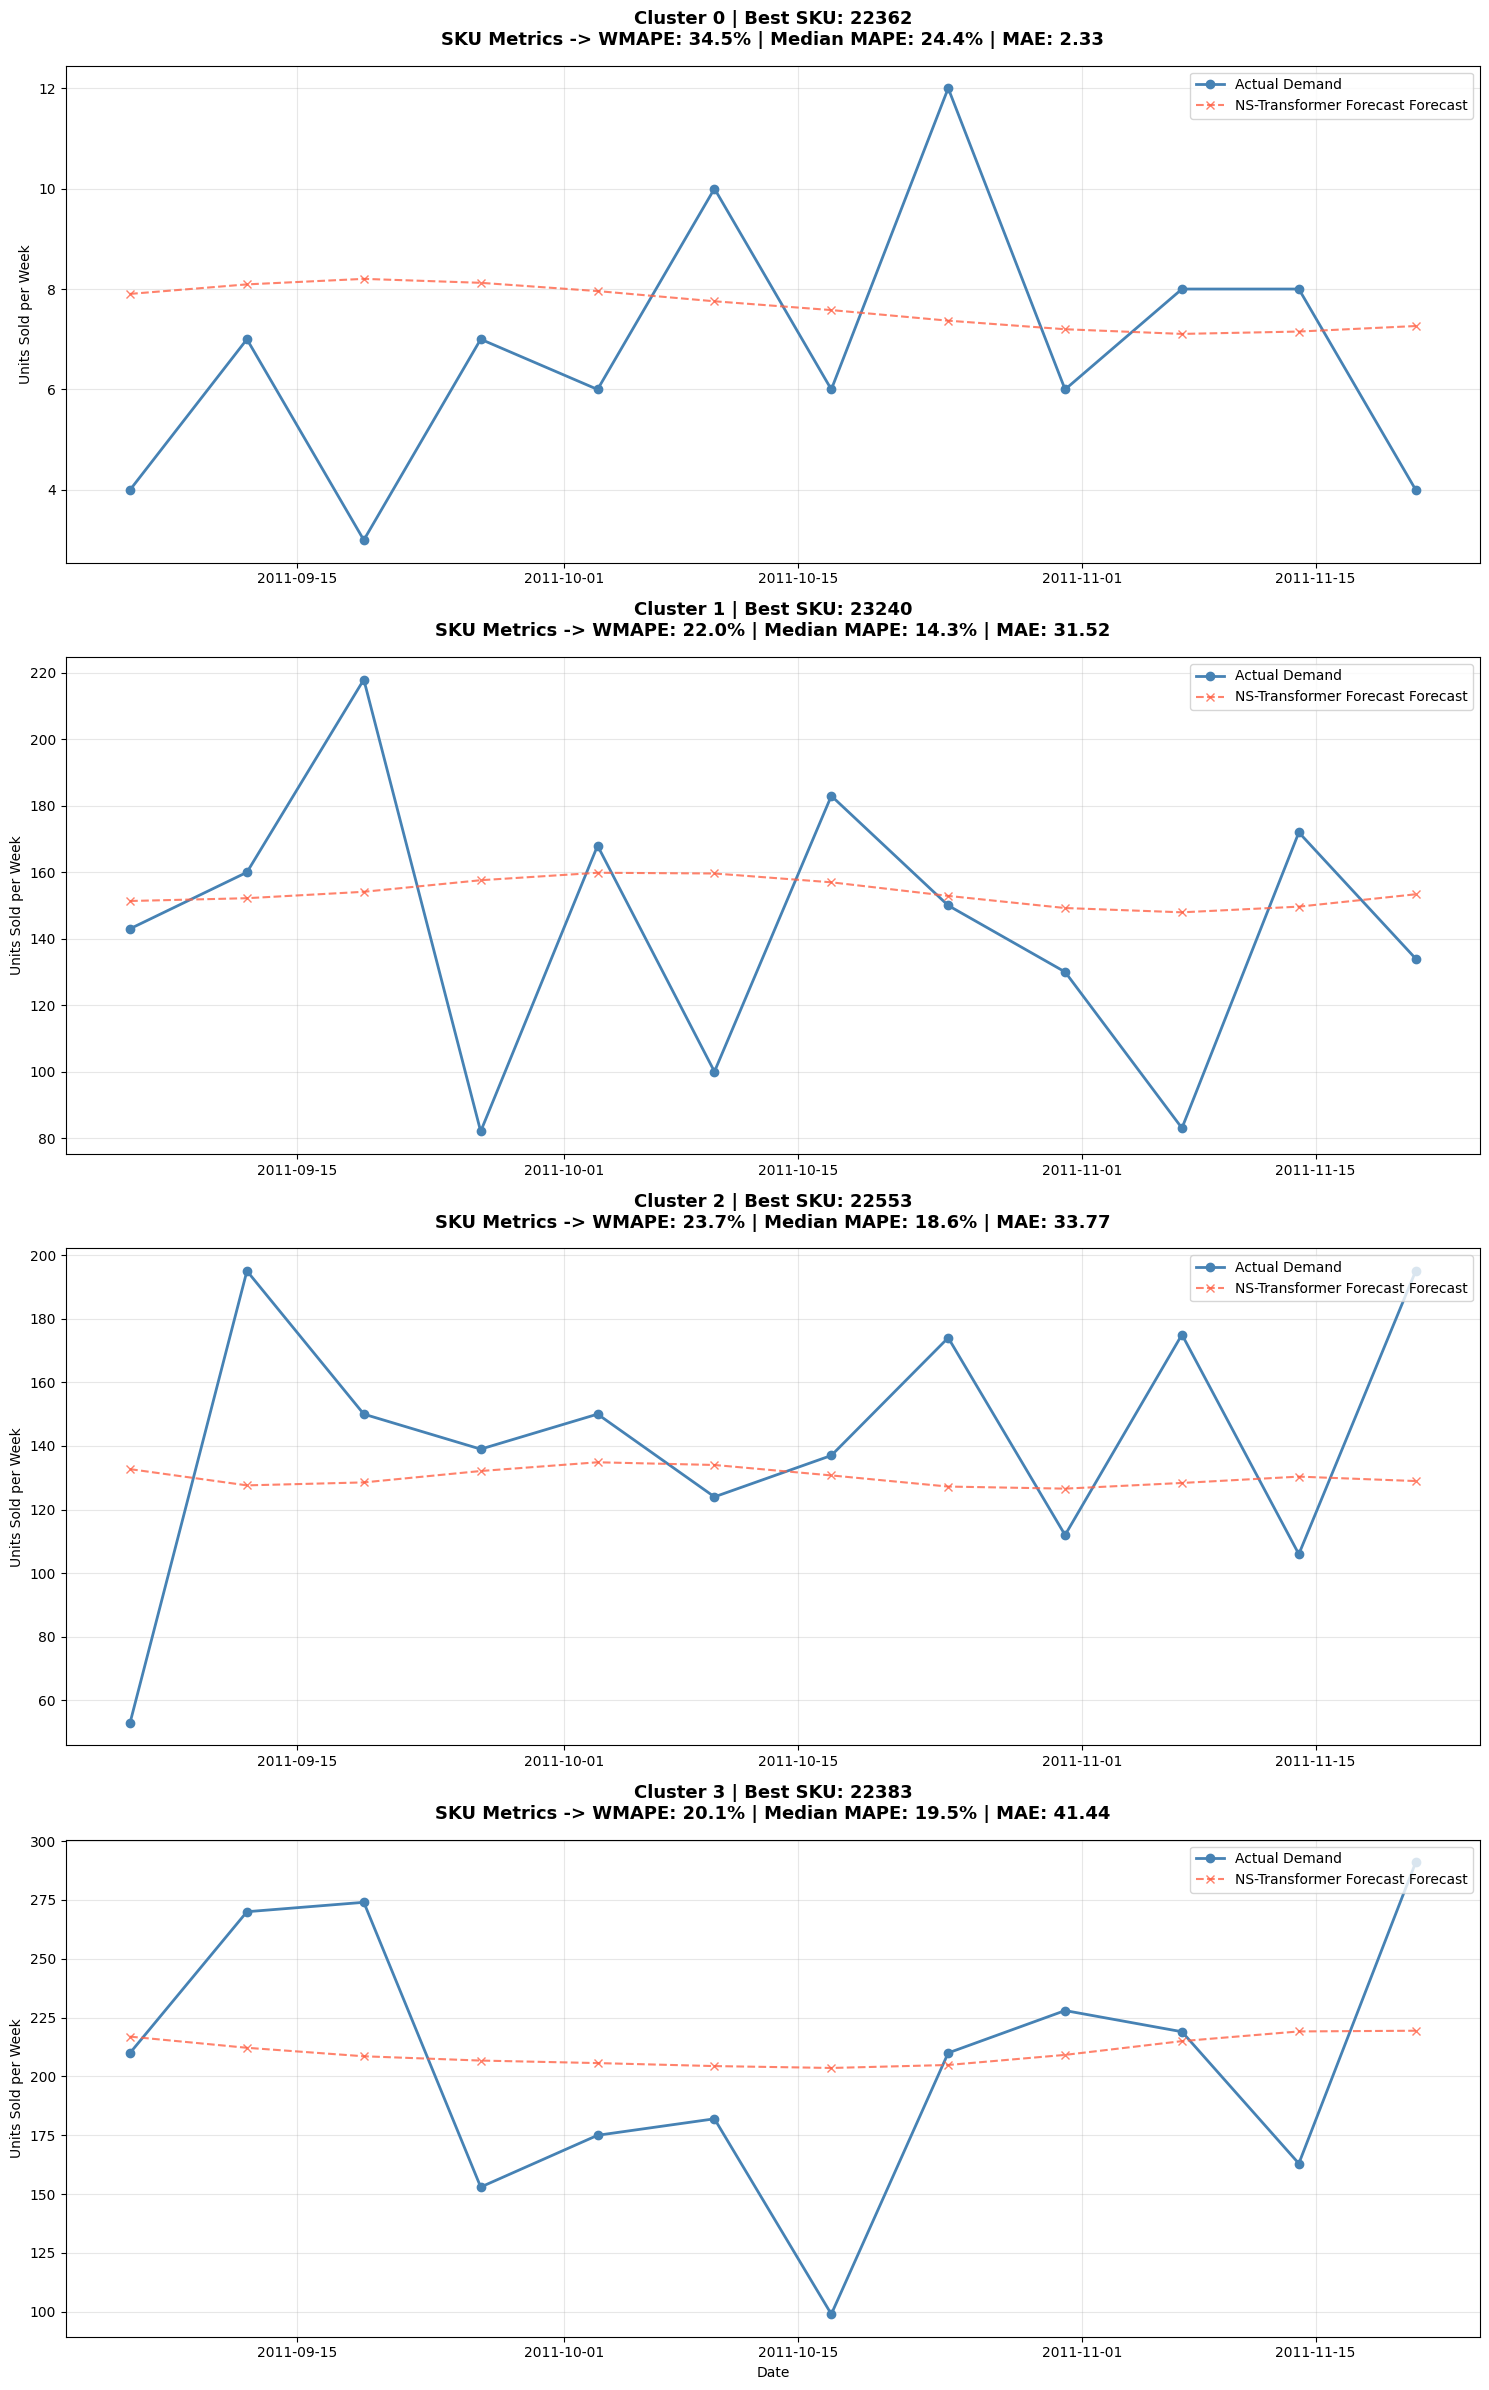

/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:188: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_metrics = cluster_eval.groupby("StockCode", observed=True).apply(calc_sku_metrics).dropna()
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning:

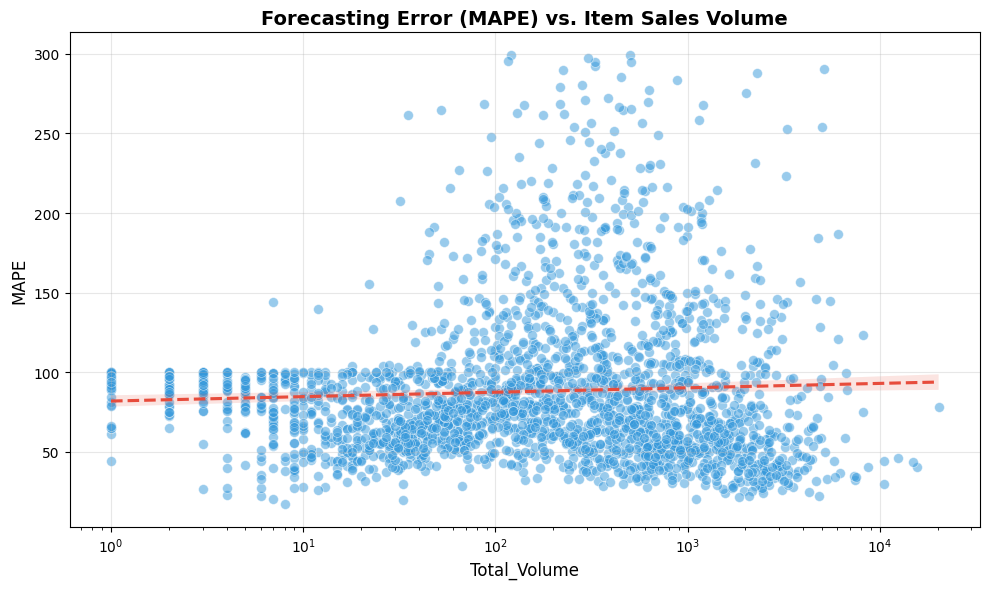

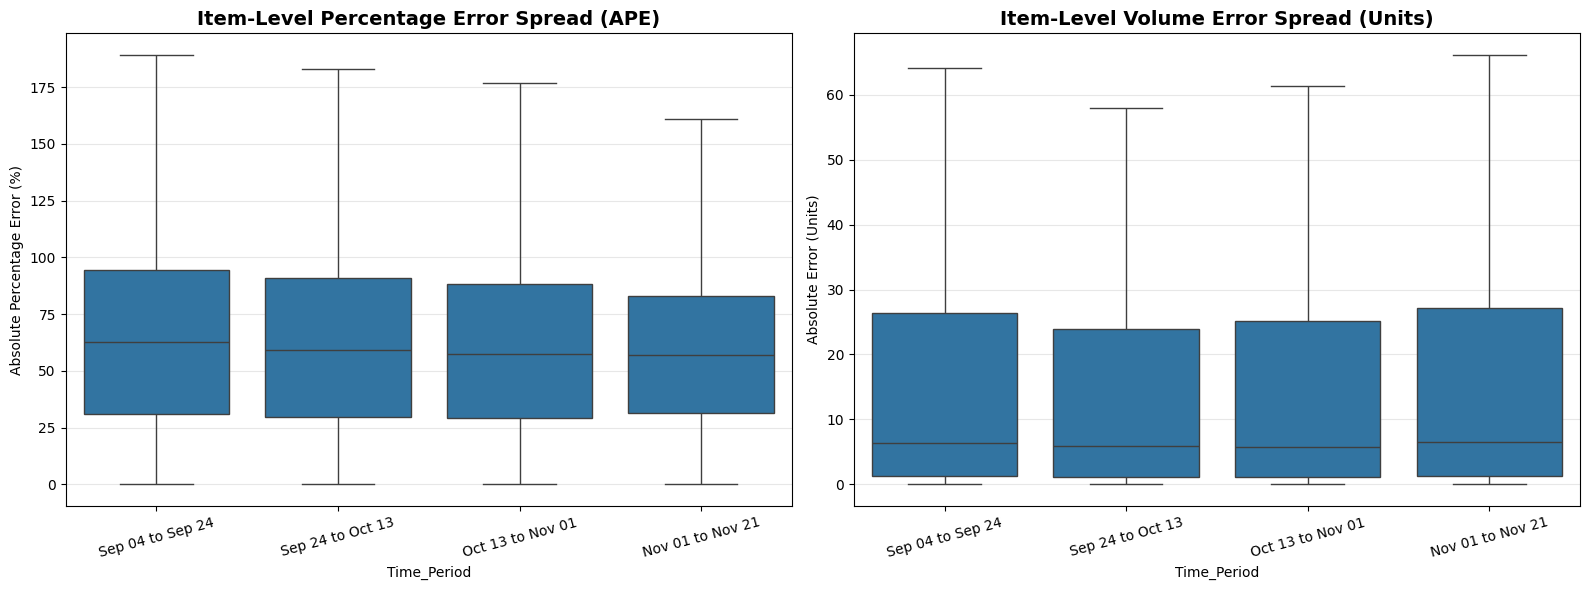

,WMAPE,Median_MAPE,Mean_Absolute_Error
Time_Period,,,
Sep 04 to Sep 24,67.37,62.83,34.22
Sep 24 to Oct 13,61.31,59.37,30.16
Oct 13 to Nov 01,59.97,57.44,32.39
Nov 01 to Nov 21,58.42,56.89,36.21


In [7]:
plot_cluster_portfolio(cluster_eval, summary, model_label="NS-Transformer Forecast")
plot_mape_vs_volume(cluster_eval)

# Analyze the drift of error over time
analyze_time_periods(test_df)  

# 7 Save Custer Artifacts

In [8]:
# Extract the SKU mapping dictionary
sku_clusters = df_long.drop_duplicates(subset=['StockCode']).set_index('StockCode')['profile_cluster_id'].to_dict()

# Save artifacts with all necessary production context
save_artifacts(cluster_models, sku_clusters)

Saving Cluster NS-Transformer artifacts to ../agent/artifacts...
Successfully saved ../agent/artifacts/nst_cluster_models.pkl
